## IRIS

In [ ]:
from google.colab import drive
mount= drive.mount('/content/drive')
dir = '/content/drive/MyDrive/fiesc/M2/files/images/base_iris/'
#

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import keras
import tensorflow as tf

# Defionição de parametros
diretorio_base = dir
tamanho_lote = 32
tamanho_imagem = (256,256)

#carregar base

dataset_treino= keras.utils.image_dataset_from_directory(
    diretorio_base,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=tamanho_imagem,
    batch_size=tamanho_lote
)

dataset_validacao= keras.utils.image_dataset_from_directory(
    diretorio_base,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=tamanho_imagem,
    batch_size=tamanho_lote
)
nomes_classe = dataset_treino.class_names


Found 421 files belonging to 3 classes.
Using 337 files for training.
Found 421 files belonging to 3 classes.
Using 84 files for validation.


In [ ]:
nomes_classe = dataset_treino.class_names
print(nomes_classe)

['iris-setosa', 'iris-versicolour', 'iris-virginica']


In [ ]:
# Otimizar performance
AUTOTUNE = tf.data.AUTOTUNE

dataset_treino = dataset_treino.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
dataset_validacao = dataset_validacao.cache().prefetch(buffer_size=AUTOTUNE)
#

Formato do tensor:  (32, 256, 256, 3)
Quantidade de labels:  (32,)


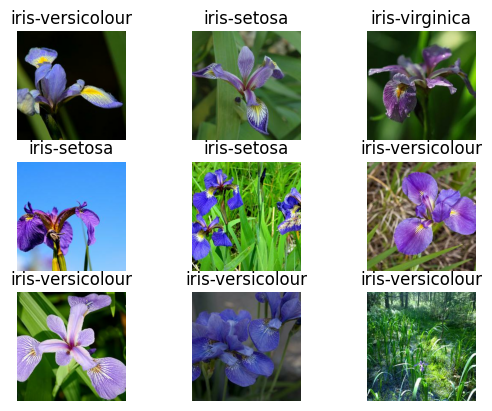

In [ ]:
import matplotlib.pyplot as plt
## AMostra do primeiro Lote#
for imagens, labels in dataset_treino.take(1):
  # INFORMAÇÕES DO LOTE
  print("Formato do tensor: ",imagens.shape)
  print("Quantidade de labels: ",labels.shape)
  for i  in range(9):
    ax = plt.subplot(3,3,i+1)

    imagem_to_plot = imagens[i].numpy().astype("uint8")
    indice_label = labels[i]
    plt.imshow(imagem_to_plot)
    plt.title(nomes_classe[indice_label])
    plt.axis("off")
#
plt.show()
#
#


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

modelo = models.Sequential([
    layers.Input(shape=(256, 256, 3)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),

    layers.Rescaling(1./255),

    # Extração de características
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Classificação
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(3, activation='softmax')
])

modelo.summary()

In [ ]:
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

parada_antecipada = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

historico_tratado = modelo.fit(
    dataset_treino,
    epochs=10,
    validation_data=dataset_validacao,
    callbacks=[parada_antecipada]
)

In [ ]:
# Visualizando os gráficos
print("--- VISUALIZANDO GRÁFICOS ----")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epocas = range(1, len(historico_tratado.history['accuracy']) + 1)

# Gráfico de Acurácia
ax1.plot(epocas, historico_tratado.history['accuracy'], label='Treino', color='blue')
ax1.plot(epocas, historico_tratado.history['val_accuracy'], label='Validação', color='orange')
ax1.set_title('Acurácia')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.legend()

# Gráfico de Perda (Loss)
ax2.plot(epocas, historico_tratado.history['loss'], label='Treino', color='blue')
ax2.plot(epocas, historico_tratado.history['val_loss'], label='Validação', color='orange')
ax2.set_title('Erro / Loss')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

## Dogs vs Cats

In [ ]:
from google.colab import drive
import tensorflow as tf
import keras
import os
import numpy as np
import matplotlib.pyplot as plt

mount= drive.mount('/content/drive')
dir_base = '/content/drive/MyDrive/fiesc/M2/files/images/dogs_vs_cats/'
# Drive das imagens:  https://drive.google.com/drive/folders/1Bc81GCEFiiqlhr595dAaHQmm1kufLlr0?usp=drive_link

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_dir = os.path.join(dir_base, 'train')
val_dir = os.path.join(dir_base, 'val')
test_dir = os.path.join(dir_base, 'test')

BATCH_SIZE = 32
IMG_SIZE = (150, 150)

In [ ]:
dataset_treino = keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
dataset_validacao = keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
# Salva os nomes das classes inferidas das subpastas (ex: ['cats', 'dogs'])
class_names = dataset_treino.class_names
print(class_names)
# Otimização de performance na leitura dos dados
AUTOTUNE = tf.data.AUTOTUNE
dataset_treino = dataset_treino.cache().prefetch(buffer_size=AUTOTUNE)
dataset_validacao = dataset_validacao.cache().prefetch(buffer_size=AUTOTUNE)

Found 11521 files belonging to 2 classes.
Found 2882 files belonging to 2 classes.
['cat', 'dog']
